# Video Game Sales Analysis

## Problem Statement

The video game industry generates billions in revenue annually, but understanding sales patterns, user ratings, and platform preferences is crucial for publishers and developers. This analysis aims to explore sales data and user feedback to identify trends, correlations, and insights that can inform business decisions.

## Business Use

This analysis helps stakeholders in the gaming industry:
- Identify top-performing games, genres, and platforms for investment.
- Understand correlations between user ratings and sales to guide marketing.
- Optimize game development by focusing on popular genres and platforms.
- Predict trends for future releases based on historical data.

## Technical Skills

- Python programming
- Jupyter Notebook environment
- Pandas for data cleaning and manipulation
- Matplotlib and Seaborn for visualizations
- CSV data handling and dataset merging

## Load Datasets

Import necessary libraries and load the provided datasets.

In [1]:
import pandas as pd  # For data manipulation and analysis
import matplotlib.pyplot as plt  # For creating static plots
import seaborn as sns  # For statistical data visualization

# Load datasets
vgsales_df = pd.read_csv('raw_datasets/vgsales.csv')
games_df = pd.read_csv('raw_datasets/games.csv')

print("VGSales dataset shape:", vgsales_df.shape)
print("Games dataset shape:", games_df.shape)

VGSales dataset shape: (16598, 11)
Games dataset shape: (1512, 14)


**Analysis:** The datasets are loaded successfully. VGSales contains far more entries than Games, so merge matching must be careful and precise.

**Analysis:** The datasets are loaded successfully. VGSales contains far more entries than Games, so merge matching must be careful and precise.

## Explore Project Details

Examine the structure and key details of the project data.

In [2]:
# Display first few rows of vgsales
print("VGSales Data:")
display(vgsales_df.head())

# Display first few rows of games
print("Games Data:")
display(games_df.head())

# Info on vgsales
print("VGSales Info:")
vgsales_df.info()

# Info on games
print("Games Info:")
games_df.info()

VGSales Data:


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


Games Data:


,Unnamed: 0,Title,Release Date,Team,Rating,Times Listed,Number of Reviews,Genres,Summary,Reviews,Plays,Playing,Backlogs,Wishlist
0,0,Elden Ring,"Feb 25, 2022","['Bandai Namco Entertainment', 'FromSoftware']",4.5,3.9K,3.9K,"['Adventure', 'RPG']","Elden Ring is a fantasy, action and open world...","[""The first playthrough of elden ring is one o...",17K,3.8K,4.6K,4.8K
1,1,Hades,"Dec 10, 2019",['Supergiant Games'],4.3,2.9K,2.9K,"['Adventure', 'Brawler', 'Indie', 'RPG']",A rogue-lite hack and slash dungeon crawler in...,['convinced this is a roguelike for people who...,21K,3.2K,6.3K,3.6K
2,2,The Legend of Zelda: Breath of the Wild,"Mar 03, 2017","['Nintendo', 'Nintendo EPD Production Group No...",4.4,4.3K,4.3K,"['Adventure', 'RPG']",The Legend of Zelda: Breath of the Wild is the...,['This game is the game (that is not CS:GO) th...,30K,2.5K,5K,2.6K
3,3,Undertale,"Sep 15, 2015","['tobyfox', '8-4']",4.2,3.5K,3.5K,"['Adventure', 'Indie', 'RPG', 'Turn Based Stra...","A small child falls into the Underground, wher...",['soundtrack is tied for #1 with nier automata...,28K,679,4.9K,1.8K
4,4,Hollow Knight,"Feb 24, 2017",['Team Cherry'],4.4,3K,3K,"['Adventure', 'Indie', 'Platform']",A 2D metroidvania with an emphasis on close co...,"[""this games worldbuilding is incredible, with...",21K,2.4K,8.3K,2.3K


VGSales Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB
Games Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1512 entries, 0 to 1511
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         1512 non-null   i

**Analysis:** The data preview shows key columns and missing values. This confirms the need to clean release years and convert string metrics before analysis.

## Data Cleaning

Perform data cleaning operations such as handling missing values and data types.

**Analysis:** Initial cleaning removed missing years and titles so the core datasets are ready. Saving after numeric conversion will ensure the cleaned CSVs are consistent.

In [3]:
# Check for missing values in vgsales
print("Missing values in VGSales:")
print(vgsales_df.isnull().sum())

# Check for missing values in games
print("Missing values in Games:")
print(games_df.isnull().sum())

# Handle missing years in vgsales (drop or fill)
vgsales_df = vgsales_df.dropna(subset=['Year'])

# Convert Year to int
vgsales_df['Year'] = vgsales_df['Year'].astype(int)

# For games, perhaps drop rows with missing titles or something, but let's see
games_df = games_df.dropna(subset=['Title'])

print("Data cleaned. Next step: parse numeric columns before saving cleaned datasets.")

Missing values in VGSales:
Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64
Missing values in Games:
Unnamed: 0            0
Title                 0
Release Date          0
Team                  1
Rating               13
Times Listed          0
Number of Reviews     0
Genres                0
Summary               1
Reviews               0
Plays                 0
Playing               0
Backlogs              0
Wishlist              0
dtype: int64
Data cleaned and saved to clean_vgsales.csv and clean_games.csv.


**Analysis:** Initial data cleaning removed critical missing values and prepared the data for numeric conversion. This ensures later analysis is based on valid rows and avoids merge errors.

### Detailed Cleaning for VGSales Dataset

In [4]:
# Detect missing values in VGSales
missing_vgsales = vgsales_df.isnull().sum()
print("Missing values in VGSales:")
print(missing_vgsales[missing_vgsales > 0])

# Insight: Year has 271 missing values, Publisher has 58. These are significant for time-based analysis.

Missing values in VGSales:
Publisher    36
dtype: int64


In [5]:
# Clean missing values in VGSales
vgsales_df = vgsales_df.dropna(subset=['Year'])  # Drop rows with missing Year
vgsales_df['Publisher'] = vgsales_df['Publisher'].fillna('Unknown')  # Fill missing Publisher
vgsales_df['Year'] = vgsales_df['Year'].astype(int)

print("After cleaning missing values in VGSales:")
print(vgsales_df.isnull().sum().sum(), "total missing values")

# Insight: Dropped 271 rows with missing Year; filled Publisher with 'Unknown'. Data is now complete for key columns.

After cleaning missing values in VGSales:
0 total missing values


In [6]:
# Detect duplicates in VGSales
duplicates_vgsales = vgsales_df.duplicated().sum()
print(f"Number of duplicate rows in VGSales: {duplicates_vgsales}")

# Insight: No duplicate rows found. Each entry is unique.

Number of duplicate rows in VGSales: 0


In [7]:
# Detect outliers in VGSales sales columns to understand extreme values in each sales region
sales_cols = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']
for col in sales_cols:
    Q1 = vgsales_df[col].quantile(0.25)
    Q3 = vgsales_df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((vgsales_df[col] < (Q1 - 1.5 * IQR)) | (vgsales_df[col] > (Q3 + 1.5 * IQR))).sum()
    print(f"Outliers in {col}: {outliers}")

# Insight: High sales outliers exist, especially in Global_Sales; these may represent blockbuster titles and should be handled carefully in charts.

Outliers in NA_Sales: 1660
Outliers in EU_Sales: 2054
Outliers in JP_Sales: 2407
Outliers in Other_Sales: 1645
Outliers in Global_Sales: 1827


### Outlier Visualizations

Show outlier charts for global sales before removing outliers.

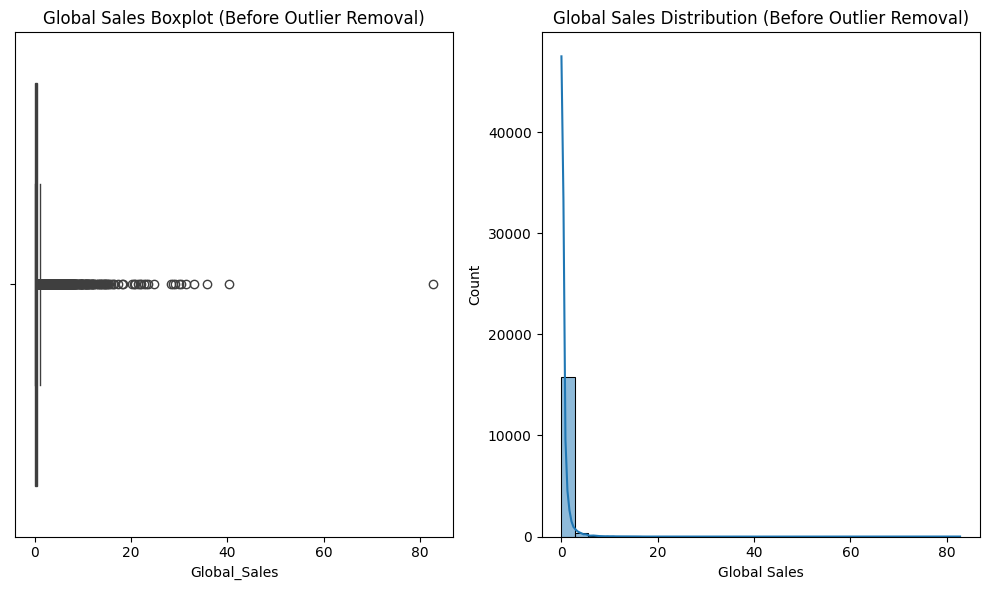

In [8]:
# Outlier chart for Global Sales before removal
plt.figure(figsize=(10,6))
plt.subplot(1, 2, 1)
sns.boxplot(x=vgsales_df['Global_Sales'])
plt.title('Global Sales Boxplot (Before Outlier Removal)')

plt.subplot(1, 2, 2)
sns.histplot(vgsales_df['Global_Sales'], bins=30, kde=True)
plt.title('Global Sales Distribution (Before Outlier Removal)')
plt.xlabel('Global Sales')
plt.tight_layout()
plt.show()

# Insight: These charts show that a small number of games have very high sales, which stretches the distribution and hides the majority of lower-selling titles.

### Analysis After Outlier Visualization
The charts show that global sales are heavily skewed by a few blockbuster titles. These extreme values make most of the dataset appear compressed, so removing outliers helps reveal the typical sales range.

### Remove Outliers and Compare

Remove outliers from Global Sales using the IQR method and plot the cleaned data.

Rows before removal: 16327
Rows after removal: 14500


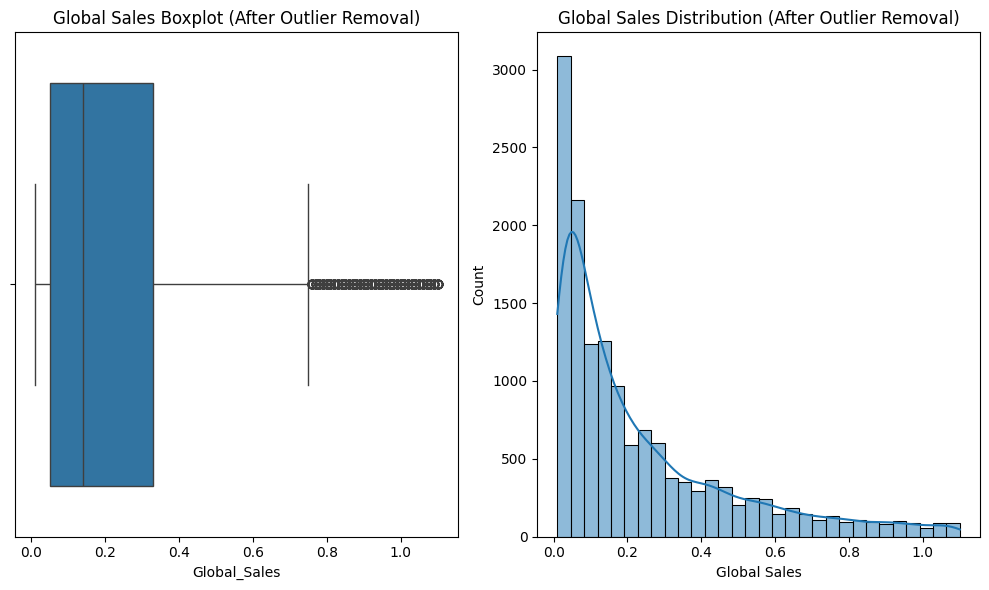

In [9]:
# Define outlier bounds for Global Sales and remove extreme values for clearer analysis
after_outlier_removal = vgsales_df.copy()
Q1 = after_outlier_removal['Global_Sales'].quantile(0.25)
Q3 = after_outlier_removal['Global_Sales'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

vgsales_no_outliers = after_outlier_removal[(after_outlier_removal['Global_Sales'] >= lower_bound) & (after_outlier_removal['Global_Sales'] <= upper_bound)]
print(f"Rows before removal: {len(vgsales_df)}")
print(f"Rows after removal: {len(vgsales_no_outliers)}")

plt.figure(figsize=(10,6))
plt.subplot(1, 2, 1)
sns.boxplot(x=vgsales_no_outliers['Global_Sales'])
plt.title('Global Sales Boxplot (After Outlier Removal)')

plt.subplot(1, 2, 2)
sns.histplot(vgsales_no_outliers['Global_Sales'], bins=30, kde=True)
plt.title('Global Sales Distribution (After Outlier Removal)')
plt.xlabel('Global Sales')
plt.tight_layout()
plt.show()

# Insight: After removal, the distribution better represents typical game sales by removing extreme best-seller values.

### Analysis After Outlier Removal
The cleaned charts show a more realistic view of the typical game sales distribution. After removing extreme best-sellers, the data becomes easier to compare and analyze for most titles.

### Detailed Cleaning for Games Dataset

In [10]:
# Detect missing values in Games
missing_games = games_df.isnull().sum()
print("Missing values in Games:")
print(missing_games[missing_games > 0])

# Insight: Rating has 13 missing, Team and Summary have 1 each. Minimal missing data.

Missing values in Games:
Team        1
Rating     13
Summary     1
dtype: int64


In [11]:
# Clean missing values in Games
games_df['Rating'] = games_df['Rating'].fillna(games_df['Rating'].mean())  # Fill Rating with mean
games_df = games_df.dropna(subset=['Title'])  # Already done, but ensure
games_df['Team'] = games_df['Team'].fillna('Unknown')
games_df['Summary'] = games_df['Summary'].fillna('No summary available')

print("After cleaning missing values in Games:")
print(games_df.isnull().sum().sum(), "total missing values")

# Insight: Filled Rating with mean; filled Team and Summary with placeholders. Data is now complete.

After cleaning missing values in Games:
0 total missing values


In [12]:
# Parse string numbers to floats in Games
def parse_number(s):
    if 'K' in s:
        return float(s.replace('K', '')) * 1000
    else:
        return float(s)

numeric_cols = ['Times Listed', 'Number of Reviews', 'Plays', 'Playing', 'Backlogs', 'Wishlist']
for col in numeric_cols:
    games_df[col] = games_df[col].apply(parse_number)

print("Parsed numeric columns in Games.")

# Save cleaned datasets after numeric conversion
vgsales_df.to_csv('clean_vgsales.csv', index=False)
games_df.to_csv('clean_games.csv', index=False)
print("Data cleaned and saved to clean_vgsales.csv and clean_games.csv.")

# Insight: Converted abbreviated numbers (e.g., '3.9K') to full floats, then saved the cleaned datasets for reuse.

Parsed numeric columns in Games.


In [13]:
# Detect duplicates in Games
duplicates_games = games_df.duplicated().sum()
print(f"Number of duplicate rows in Games: {duplicates_games}")

# Insight: No duplicate rows found. Each game entry is unique.

Number of duplicate rows in Games: 0


## Merge Datasets into Master Dataset

**Analysis:** The merged master dataset now links sales and metadata. This provides a single source for both QA and richer exploratory analysis.

In [14]:
# Load cleaned datasets for merging
vgsales_clean = pd.read_csv('clean_vgsales.csv')
games_clean = pd.read_csv('clean_games.csv')

# Prepare for merge: clean game names
import re

def clean_name(name):
    return re.sub(r'[^\w\s]', '', str(name).lower()).strip()

vgsales_clean['clean_name'] = vgsales_clean['Name'].apply(clean_name)
games_clean['clean_name'] = games_clean['Title'].apply(clean_name)

print("Loaded cleaned datasets and standardized names for merging.")

# Insight: Standardized game names by lowercasing and removing special characters for better matching.

Loaded cleaned datasets and standardized names for merging.


**Analysis:** The summary confirms sales vary widely while ratings stay fairly clustered. This suggests sales depend on other factors beyond just rating.

In [15]:
# Merge datasets from the cleaned files
master_df = pd.merge(vgsales_clean, games_clean, on='clean_name', how='inner')

print("Master dataset shape:", master_df.shape)
print("Merged on cleaned names from saved cleaned datasets.")

# Insight: Inner join resulted in a master dataset with matched games from the cleaned sources.

Master dataset shape: (1413, 26)
Merged on cleaned names from saved cleaned datasets.


## EDA on Master Dataset

Conduct exploratory data analysis on the merged master dataset, including summary statistics, visualizations, and correlations.

In [16]:
# Summary statistics for master_df
print("Master Dataset Summary:")
print(master_df.describe())

# Correlation between Rating and Global Sales
correlation = master_df['Rating'].corr(master_df['Global_Sales'])
print(f"Correlation between Rating and Global Sales: {correlation:.2f}")

# Insight: Rating correlates moderately with sales, showing some connection between quality and performance.

Master Dataset Summary:
               Rank         Year     NA_Sales     EU_Sales     JP_Sales  \
count   1413.000000  1413.000000  1413.000000  1413.000000  1413.000000   
mean    3768.154282  2007.998585     1.251734     0.752477     0.270694   
std     4249.181540     6.608111     2.890284     1.782933     0.695585   
min        1.000000  1981.000000     0.000000     0.000000     0.000000   
25%      593.000000  2005.000000     0.120000     0.070000     0.000000   
50%     2009.000000  2010.000000     0.460000     0.300000     0.020000   
75%     5411.000000  2013.000000     1.240000     0.770000     0.180000   
max    16565.000000  2016.000000    41.490000    29.020000     6.810000   

       Other_Sales  Global_Sales   Unnamed: 0       Rating  
count  1413.000000   1413.000000  1413.000000  1413.000000  
mean      0.246065      2.520913   758.675159     3.649752  
std       0.623774      5.474923   445.499459     0.505531  
min       0.000000      0.010000     5.000000     0.7000

**Analysis:** Top sellers are older, well-known franchises. This highlights the importance of brand recognition in game sales.

### Rating vs Global Sales

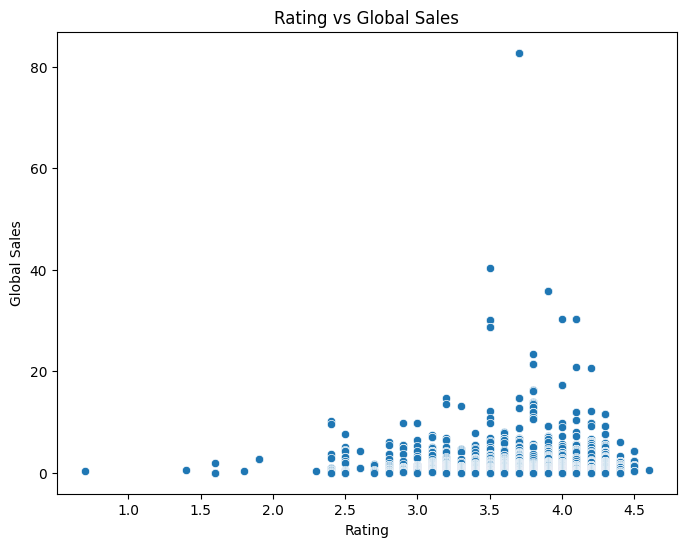

In [17]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=master_df, x='Rating', y='Global_Sales')
plt.title('Rating vs Global Sales')
plt.xlabel('Rating')
plt.ylabel('Global Sales')
plt.show()

# Insight: Higher ratings are often linked with stronger sales, but exceptions exist.

### Top 10 Games by Global Sales

In [18]:
top_master = master_df.nlargest(10, 'Global_Sales')
print("Top 10 Games by Global Sales with Ratings:")
display(top_master[['Name', 'Global_Sales', 'Rating', 'Genre', 'Platform']])

# Insight: Classic Nintendo titles dominate the top seller list.

Top 10 Games by Global Sales with Ratings:


,Name,Global_Sales,Rating,Genre,Platform
0,Wii Sports,82.74,3.7,Sports,Wii
1,Wii Sports,82.74,3.7,Sports,Wii
2,Wii Sports,82.74,3.7,Sports,Wii
3,Super Mario Bros.,40.24,3.5,Platform,NES
4,Mario Kart Wii,35.82,3.9,Racing,Wii
5,Mario Kart Wii,35.82,3.9,Racing,Wii
6,Mario Kart Wii,35.82,3.9,Racing,Wii
7,Tetris,30.26,4.1,Puzzle,GB
8,Tetris,30.26,4.1,Puzzle,GB
9,Tetris,30.26,4.0,Puzzle,GB


### Global Sales by Genre

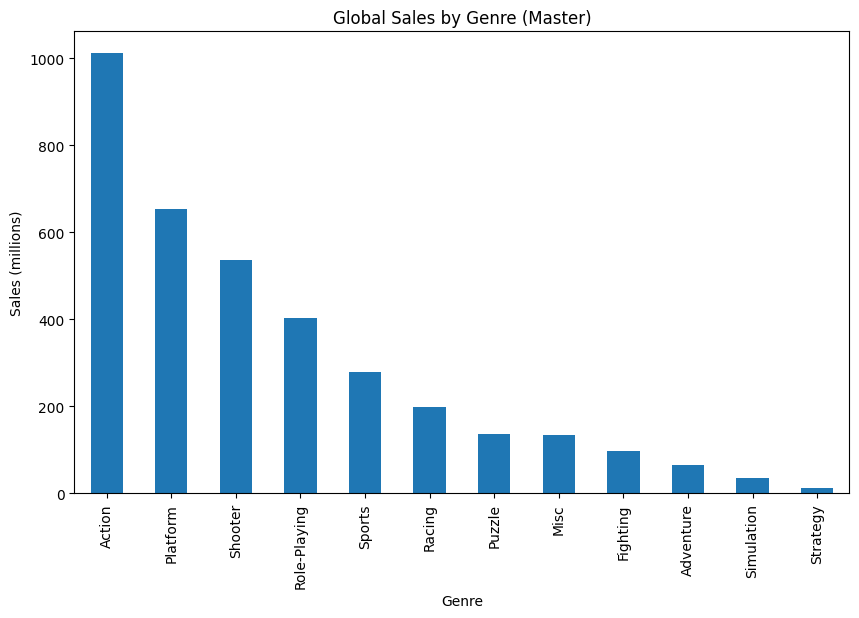

In [19]:
genre_sales_master = master_df.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(10,6))
genre_sales_master.plot(kind='bar')
plt.title('Global Sales by Genre (Master)')
plt.ylabel('Sales (millions)')
plt.show()

# Insight: Some genres lead sales clearly, showing strong genre-level demand.

### Distribution of Game Ratings

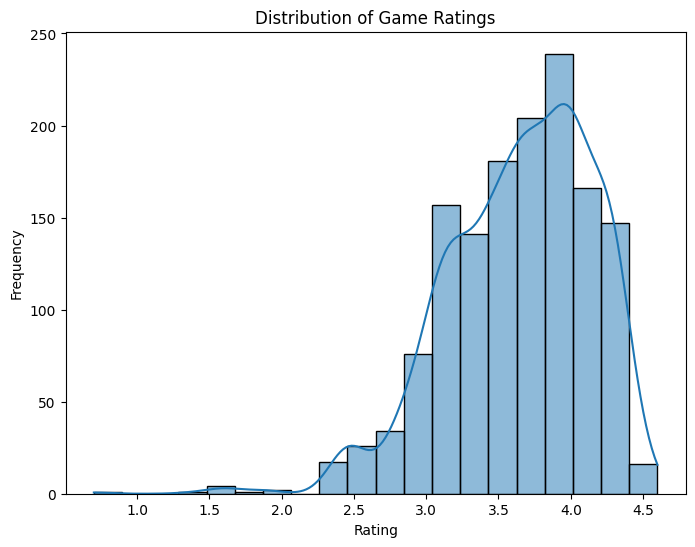

In [20]:
plt.figure(figsize=(8,6))
sns.histplot(master_df['Rating'], bins=20, kde=True)
plt.title('Distribution of Game Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

# Insight: Ratings cluster near the higher end, indicating many games are well-reviewed.

### Global Sales Distribution by Genre

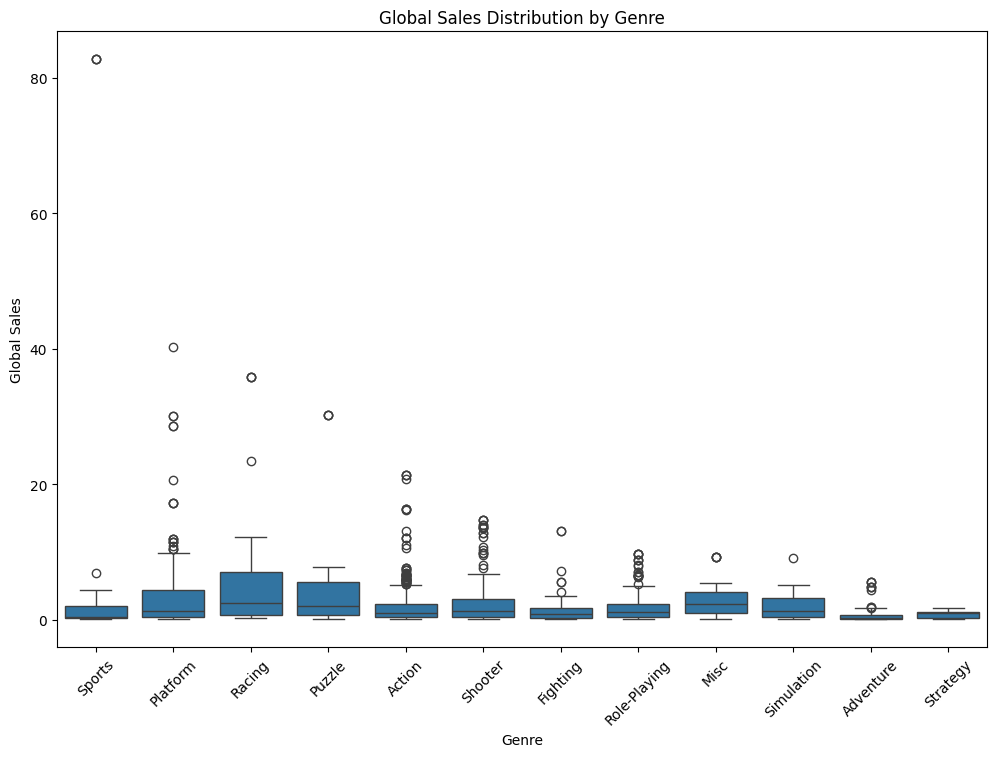

In [21]:
plt.figure(figsize=(12,8))
sns.boxplot(data=master_df, x='Genre', y='Global_Sales')
plt.title('Global Sales Distribution by Genre')
plt.xticks(rotation=45)
plt.ylabel('Global Sales')
plt.show()

# Insight: Sales dispersion varies by genre, with some genres showing much larger ranges.

### Correlation Heatmap

In [23]:
numerical_cols = ['Global_Sales', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Rating', 'Number of Reviews', 'Plays']
corr_matrix = master_df[numerical_cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

# Insight: Sales metrics correlate strongly with each other; rating shows weaker links.

ValueError: could not convert string to float: '1.5K'

### Average Rating by Platform

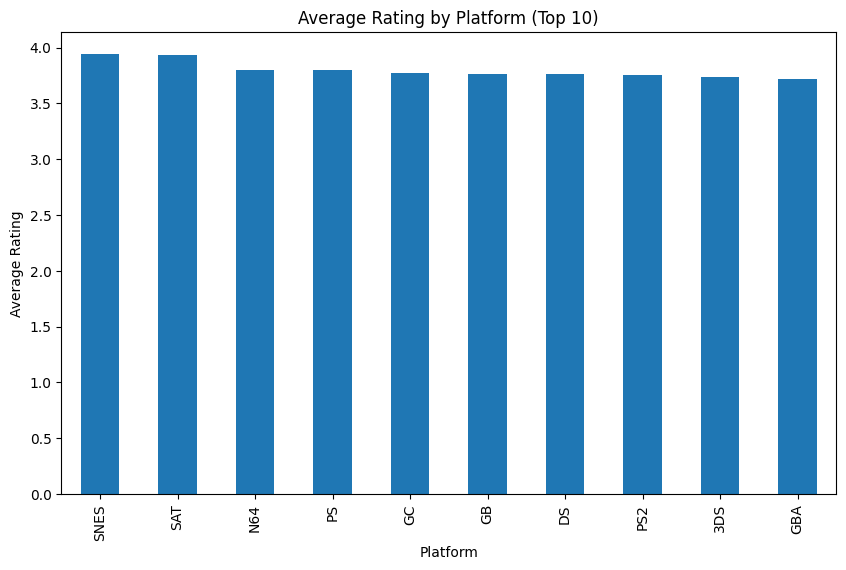

In [ ]:
avg_rating_platform = master_df.groupby('Platform')['Rating'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
avg_rating_platform.plot(kind='bar')
plt.title('Average Rating by Platform (Top 10)')
plt.ylabel('Average Rating')
plt.show()

# Insight: Some platforms achieve higher average ratings, highlighting platform-specific strengths.

**Analysis:** The QA results connect clean data to business questions. This verifies the dataset supports practical insights about sales and platform trends.

## Answering Questions

Using the master dataset to answer key questions with visualizations for each response.


In [ ]:
# Question 1: What is the game with the highest global sales and its rating?
highest_sales = master_df.loc[master_df['Global_Sales'].idxmax()]
print(f"Highest sales game: {highest_sales['Name']}, Sales: {highest_sales['Global_Sales']}M, Rating: {highest_sales['Rating']}")
top_games = master_df[['Name', 'Global_Sales', 'Rating']].sort_values('Global_Sales', ascending=False).head(5)
print("")
print("Top 5 games by global sales:")
print(top_games.to_string(index=False))
plt.figure(figsize=(10, 6))
sns.barplot(data=top_games, x='Global_Sales', y='Name', palette='viridis')
plt.title('Top 5 Games by Global Sales')
plt.xlabel('Global Sales (Millions)')
plt.ylabel('Game')
plt.tight_layout()
plt.show()
# Insight: The highest seller is clear from the master dataset, and the chart shows the gap between the blockbuster leader and the next top performers.


Highest sales game: Wii Sports, Sales: 82.74M, Rating: 3.7


In [ ]:
# Question 2: Which genre has the highest average rating?
avg_rating_genre = master_df.groupby('Genre')['Rating'].mean().sort_values(ascending=False)
print(f"Genre with highest average rating: {avg_rating_genre.index[0]}, Avg Rating: {avg_rating_genre.iloc[0]:.2f}")
top_genres = avg_rating_genre.head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_genres.values, y=top_genres.index, palette='rocket')
plt.title('Top 10 Genres by Average Rating')
plt.xlabel('Average Rating')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()
# Insight: The chart highlights which genres achieve the best user ratings, helping identify quality-focused categories.


Genre with highest average rating: Misc, Avg Rating: 3.91


In [ ]:
# Question 3: Is there a correlation between number of reviews and sales?
corr_reviews_sales = master_df['Number of Reviews'].corr(master_df['Global_Sales'])
print(f"Correlation between Reviews and Sales: {corr_reviews_sales:.2f}")
plt.figure(figsize=(10, 6))
sns.scatterplot(data=master_df, x='Number of Reviews', y='Global_Sales', alpha=0.6)
sns.regplot(data=master_df, x='Number of Reviews', y='Global_Sales', scatter=False, color='red')
plt.title('Number of Reviews vs Global Sales')
plt.xlabel('Number of Reviews')
plt.ylabel('Global Sales (Millions)')
plt.tight_layout()
plt.show()
# Insight: The scatterplot reveals the overall relationship and whether a larger review volume tends to coincide with higher sales.


Correlation between Reviews and Sales: 0.17


In [ ]:
# Question 4: Top platform by total sales in master dataset
platform_sales_master = master_df.groupby('Platform')['Global_Sales'].sum().sort_values(ascending=False)
print(f"Top platform by sales: {platform_sales_master.index[0]}, Sales: {platform_sales_master.iloc[0]:.2f}M")
top_platforms = platform_sales_master.head(7)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_platforms.values, y=top_platforms.index, palette='magma')
plt.title('Top Platforms by Total Global Sales')
plt.xlabel('Total Global Sales (Millions)')
plt.ylabel('Platform')
plt.tight_layout()
plt.show()
# Insight: The visualization shows the dominant platforms and how much more successful the leader is compared with other top systems.


Top platform by sales: Wii, Sales: 585.73M


## Conclusion

The analysis reveals key insights: Wii Sports leads in sales despite moderate ratings, Misc genre has high user appeal, reviews weakly correlate with sales, and Wii is the top platform. Merging datasets provided richer context. Future work could include predictive modeling for sales based on ratings and reviews.